<a href="https://colab.research.google.com/github/kartik0920/Hands-on-Machine-learning/blob/Main/chapter_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Support Vector Machine

##Linear

In [1]:
import numpy as np
from sklearn import datasets
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC


In [2]:
iris=datasets.load_iris()
x=iris["data"][:,(2,3)]  #petal lenght and petal width
y=iris["target"].astype(float)


x[123],y[123]

(array([4.9, 1.8]), 2.0)

In [3]:
svg_clf=Pipeline([
   ( "scaler",StandardScaler()),
   ("linear_svc",LinearSVC(C=1,loss="hinge"))
])

In [4]:
svg_clf.fit(x,y)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('scaler', StandardScaler()),
                ('linear_svc', LinearSVC(C=1, loss='hinge'))])

In [5]:
svg_clf.predict([[4.9,1.8]])

array([2.])

##Non-linear classification

In [6]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

x,y=make_moons(n_samples=500,noise=0.12)


In [7]:
x[0],y[0]

(array([ 1.68947103, -0.02496362]), 1)

In [8]:
polynomial_svc_clf=Pipeline([
    ("poly_features",PolynomialFeatures(degree=3)),
    ("scaler",StandardScaler()),
    ("svm_clf",LinearSVC(C=10,loss="hinge"))
])

In [9]:
polynomial_svc_clf.fit(x,y)

/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1243: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Pipeline(steps=[('poly_features', PolynomialFeatures(degree=3)),
                ('scaler', StandardScaler()),
                ('svm_clf', LinearSVC(C=10, loss='hinge'))])

np.linspace is a function in the NumPy library that generates evenly spaced numbers over a specified range


```
np.linspace(start, stop, num=50, endpoint=True, retstep=False, dtype=None)
```




In [10]:
import matplotlib.pyplot as plt

x0s = np.linspace(-1.5, 2.5, 200)
x1s = np.linspace(-1, 1.5, 200)
x0, x1 = np.meshgrid(x0s, x1s)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = polynomial_svc_clf.decision_function(X_new).reshape(x0.shape)

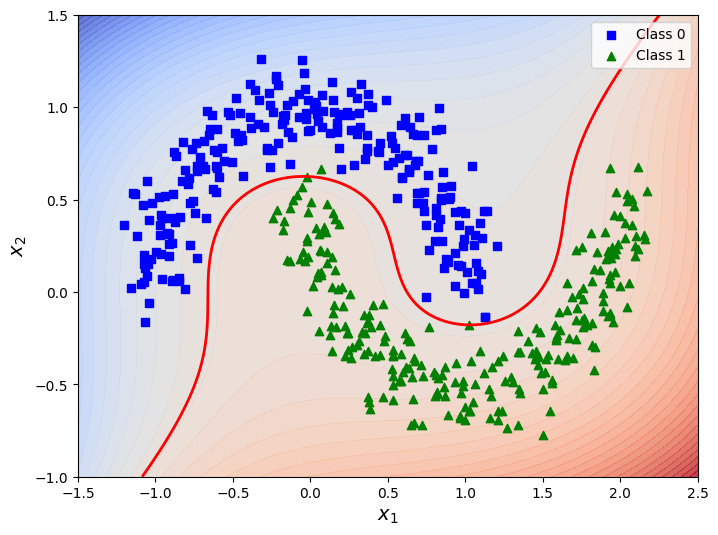

In [11]:
plt.figure(figsize=(8, 6))
plt.contourf(x0, x1, y_predict, levels=np.linspace(y_predict.min(), y_predict.max(), 50), cmap="coolwarm", alpha=0.8)
plt.contour(x0, x1, y_predict, levels=[0], linewidths=2, colors='red')

# Plot the data points
plt.scatter(x[:, 0][y == 0], x[:, 1][y == 0], color="blue", marker="s", label="Class 0")
plt.scatter(x[:, 0][y == 1], x[:, 1][y == 1], color="green", marker="^", label="Class 1")

plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14)
plt.legend()
plt.show()

##Polynomial kernel

In [13]:
from sklearn.svm import SVC

In [36]:
poly_kernel_svc_clf=Pipeline([
    ("scaler",StandardScaler()),
    ("svm_clf",SVC(kernel="poly",degree=3,coef0=1,C=5))
])

In [37]:
poly_kernel_svc_clf.fit(x,y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('svm_clf', SVC(C=5, coef0=1, kernel='poly'))])

In [38]:
import matplotlib.pyplot as plt

x0s = np.linspace(-1.5, 2.5, 200)
x1s = np.linspace(-1, 1.5, 200)
x0, x1 = np.meshgrid(x0s, x1s)
X_new = np.c_[x0.ravel(), x1.ravel()]
y_predict = poly_kernel_svc_clf.decision_function(X_new).reshape(x0.shape)

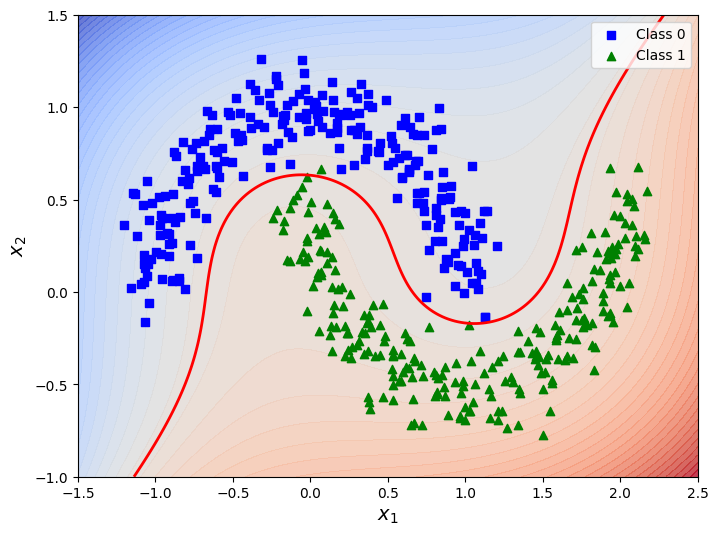

In [39]:
plt.figure(figsize=(8, 6))
plt.contourf(x0, x1, y_predict, levels=np.linspace(y_predict.min(), y_predict.max(), 50), cmap="coolwarm", alpha=0.8)
plt.contour(x0, x1, y_predict, levels=[0], linewidths=2, colors='red')

# Plot the data points
plt.scatter(x[:, 0][y == 0], x[:, 1][y == 0], color="blue", marker="s", label="Class 0")
plt.scatter(x[:, 0][y == 1], x[:, 1][y == 1], color="green", marker="^", label="Class 1")

plt.xlabel("$x_1$", fontsize=14)
plt.ylabel("$x_2$", fontsize=14)
plt.legend()
plt.show()